# **ANÁLISE EXPLORATÓRIA E VISUALIZAÇÃO DE DADOS**
### *Estudo de Caso 1 — Arrecadação Federal de Impostos (2024)*

**Advanced MBA | Pós-Graduação — Analytics e IA / Data Science — FIA**

**Time Responsável**
- Renan Correia de Faria (Líder)
- Bruno Umeoka Higuti
- Hygor Vaz de Souza Barbosa
- Michelle Arisa Tanaka
- Victor Aquino

## **1. Carregamento de bibliotecas**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## **2. Leitura e inspeção inicial dos dados**

In [ ]:
dados = pd.read_table('Estudo_Caso_1_Base_I_Dados.txt',
                      sep='\t',
                      decimal='.',
                      header=0)

In [ ]:
# Inspeção das primeiras linhas
dados.head()

,natureza_juridica_codigo,natureza_juridica_descricao,natureza_juridica_escopo,imposto_importacao,imposto_exportacao,ipi,irpf,irpj,irrf,iof,itr,cofins,pis_pasep,csll,cide_combustiveis,contribuicao_previdenciaria,cpsss,pagamento_unificado,outras_receitas_rfb,demais_receitas
0,1015,Órgão Público do Poder Executivo Federal,embaixadas. os consulados. os escritórios de r...,137030.42,0.0,15804.59,0.0,80855586.13,1.195182e+10,73899.77,1890.51,13512943.62,3.354831e+09,15281637.04,1872850.17,1.023143e+09,6.448526e+09,1.092729e+09,19391632.56,2.458620e+08
1,1023,Órgão Público do Poder Executivo Estadual ou d...,órgãos públicos do Poder Executivo dos Estados...,18.70,0.0,0.00,0.0,38363.54,1.942367e+06,0.00,1209.82,174736.97,8.768773e+08,51807.58,19491.23,8.631348e+09,0.000000e+00,3.108754e+07,2214398.77,1.965731e+06
2,1031,Órgão Público do Poder Executivo Municipal,os órgãos públicos do Poder Executivo dos Muni...,0.00,0.0,0.00,0.0,131.03,1.127281e+05,684.00,10.00,4150.98,3.322070e+07,3193.65,0.00,1.335825e+09,1.137880e+03,5.855485e+04,1124862.03,1.280702e+05
3,1040,Órgão Público do Poder Legislativo Federal,os órgãos públicos do Poder Legislativo Federal,0.00,0.0,0.00,0.0,180172.30,1.177167e+09,0.00,0.00,291979.76,6.325578e+04,172395.48,24411.86,3.473305e+08,8.642313e+08,6.574583e+07,0.00,4.350921e+04
4,1058,Órgão Público do Poder Legislativo Estadual ou...,os órgãos públicos do Poder Legislativo dos Es...,0.00,0.0,0.00,0.0,0.00,1.859932e+04,0.00,0.00,71701.41,1.020950e+06,23900.46,0.00,1.127164e+09,1.315068e+05,1.072480e+05,5606526.19,0.000000e+00


In [ ]:
# Quantidade de linhas e colunas
dados.shape

(83, 20)

In [ ]:
# Tipos das colunas
dados.dtypes

,0
natureza_juridica_codigo,int64
natureza_juridica_descricao,object
natureza_juridica_escopo,object
imposto_importacao,float64
imposto_exportacao,float64
ipi,float64
irpf,float64
irpj,float64
irrf,float64
iof,float64


## **3. Análises de unicidade e preenchimento**

A chave de análise é a `natureza_juridica_codigo`. Verificamos duplicidades nos campos-chave e tratamos os casos conforme o critério de completude.

*Verificação de duplicidade nos campos-chave*

In [ ]:
dados[['natureza_juridica_codigo']].duplicated().sum()

np.int64(0)

In [ ]:
dados[['natureza_juridica_descricao']].duplicated().sum()

np.int64(2)

In [ ]:
dados[['natureza_juridica_escopo']].duplicated().sum()

np.int64(1)

*Registros com **descrição** duplicada*

As linhas 35/36 e 64/65 têm a mesma descrição e todos os valores de recolhimento iguais. Apesar do código diferente, optamos por excluir uma linha de cada par.

In [ ]:
dados[dados[['natureza_juridica_descricao']].duplicated(keep=False)]

,natureza_juridica_codigo,natureza_juridica_descricao,natureza_juridica_escopo,imposto_importacao,imposto_exportacao,ipi,irpf,irpj,irrf,iof,itr,cofins,pis_pasep,csll,cide_combustiveis,contribuicao_previdenciaria,cpsss,pagamento_unificado,outras_receitas_rfb,demais_receitas
35,2070,Sociedade Empresária em Nome Coletivo,as entidades dotadas de personalidade jurídica...,70568.29,0.0,13240.59,0.00,5620525.09,5.421873e+05,35.78,9016.98,3916402.82,816673.18,3648631.15,0.00,7.089979e+06,0.00,342714.56,89645.11,325992.38
36,2076,Sociedade Empresária em Nome Coletivo,as entidades dotadas de personalidade jurídica...,70568.29,0.0,13240.59,0.00,5620525.09,5.421873e+05,35.78,9016.98,3916402.82,816673.18,3648631.15,0.00,7.089979e+06,0.00,342714.56,89645.11,325992.38
64,3130,Entidade Sindical,sindicatos. federações. confederações e centra...,157797.05,0.0,209505.83,588.32,2834898.76,3.856108e+08,219366.73,187611.29,34701416.13,19074717.94,1982628.43,145425.57,6.295994e+08,31886.96,39797109.66,9903651.36,23760888.49
65,3131,Entidade Sindical,os sindicatos. federações. confederações e cen...,157797.05,0.0,209505.83,588.32,2834898.76,3.856108e+08,219366.73,187611.29,34701416.13,19074717.94,1982628.43,145425.57,6.295994e+08,31886.96,39797109.66,9903651.36,23760888.49


*Registros com **escopo** duplicado*

As linhas 44/45 têm escopo duplicado, mas descrições e valores de recolhimento diferentes. Por isso, **mantivemos ambas**.

In [ ]:
dados[dados[['natureza_juridica_escopo']].duplicated(keep=False)]

,natureza_juridica_codigo,natureza_juridica_descricao,natureza_juridica_escopo,imposto_importacao,imposto_exportacao,ipi,irpf,irpj,irrf,iof,itr,cofins,pis_pasep,csll,cide_combustiveis,contribuicao_previdenciaria,cpsss,pagamento_unificado,outras_receitas_rfb,demais_receitas
44,2160,Grupo de Sociedades,as sociedades que se encontram sob controle co...,0.0,0.0,0.00,0.0,4.149313e+04,1.420390e+03,0.00,0.00,0.0,0.0,9697.03,0.00,0.000000e+00,0.0,7381.89,3889.55,37356.45
45,2178,Estabelecimento. no Brasil. de Sociedade Estra...,as sociedades que se encontram sob controle co...,243124093.6,0.0,3634480.14,0.0,1.034502e+08,2.485679e+08,3190861.12,272.36,79566221.4,17253344.5,57593902.12,4970218.82,2.856365e+08,0.0,27232574.77,17736866.46,4370682.05


*Exclusão de linhas inteiras duplicadas*

In [ ]:
dados = dados.drop_duplicates()

*Exclusão manual das linhas parcialmente duplicadas (sem divergência de informação), mantendo o registro de maior completude*

In [ ]:
dados = dados.drop([35])
dados = dados.drop([64])

*Nova contabilização de duplicidade na chave (após o tratamento)*

In [ ]:
dados[['natureza_juridica_descricao']].duplicated().sum()

np.int64(0)

*Contabilização de valores ausentes em cada variável*

In [ ]:
dados.isna().sum()

,0
natureza_juridica_codigo,0
natureza_juridica_descricao,0
natureza_juridica_escopo,0
imposto_importacao,0
imposto_exportacao,0
ipi,0
irpf,0
irpj,0
irrf,0
iof,0


*Porcentagem de valores ausentes em cada variável*

In [ ]:
dados.isnull().mean().round(3) * 100

,0
natureza_juridica_codigo,0.0
natureza_juridica_descricao,0.0
natureza_juridica_escopo,0.0
imposto_importacao,0.0
imposto_exportacao,0.0
ipi,0.0
irpf,0.0
irpj,0.0
irrf,0.0
iof,0.0


# **4. Análise univariada**

Exploramos primeiro a variável qualitativa (natureza jurídica) e, em seguida, as variáveis quantitativas (tributos).

*Tabela de frequências — variável qualitativa (natureza jurídica)*

In [ ]:
var_quali = dados['natureza_juridica_descricao']
var_quali.value_counts(dropna=False)

#Cada nautureza juridica na base é única

,count
natureza_juridica_descricao,
Órgão Público do Poder Executivo Federal,1
Órgão Público do Poder Executivo Estadual ou do Distrito Federal,1
Órgão Público do Poder Executivo Municipal,1
Órgão Público do Poder Legislativo Federal,1
Órgão Público do Poder Legislativo Estadual ou do Distrito Federal,1
...,...
Candidato a Cargo Político Eletivo,1
Produtor Rural (Pessoa Física),1
Organização Internacional,1


In [ ]:
# Frequências relativas (%)
var_quali.value_counts(dropna=False, normalize=True).round(3) * 100

,proportion
natureza_juridica_descricao,
Órgão Público do Poder Executivo Federal,1.2
Órgão Público do Poder Executivo Estadual ou do Distrito Federal,1.2
Órgão Público do Poder Executivo Municipal,1.2
Órgão Público do Poder Legislativo Federal,1.2
Órgão Público do Poder Legislativo Estadual ou do Distrito Federal,1.2
...,...
Candidato a Cargo Político Eletivo,1.2
Produtor Rural (Pessoa Física),1.2
Organização Internacional,1.2


### Distribuição da arrecadação por tributo

Consolidamos a soma de cada tributo e sua participação no total arrecadado.

In [ ]:
tributos = [c for c in dados.columns
            if c not in ['natureza_juridica_codigo', 'natureza_juridica_descricao', 'natureza_juridica_escopo']]

total_por_tributo = dados[tributos].sum().sort_values(ascending=False)
tab_tributos = pd.DataFrame({
    'Total (R$ bi)': (total_por_tributo / 1e9).round(1),
    '% do total': (total_por_tributo / total_por_tributo.sum() * 100).round(1)
})
tab_tributos

#Aqui identificamos um risco e dependência grande de arrecadação concentrado em poucos impostos: Contribuição previdenciaria, IRRF, COFINS, IRPJ.

,Total (R$ bi),% do total
contribuicao_previdenciaria,399.5,24.2
irrf,287.3,17.4
cofins,251.5,15.2
irpj,217.0,13.1
csll,113.0,6.8
demais_receitas,82.5,5.0
pis_pasep,69.9,4.2
ipi,50.4,3.1
imposto_importacao,46.9,2.8
iof,43.3,2.6


In [ ]:
# Em quantas naturezas cada tributo incide (valor > 0)
qtd_naturezas_por_tributo = (dados[tributos] > 0).sum(axis=0).sort_values(ascending=False)
tab_por_tributo = pd.DataFrame({
    'Nº de naturezas': qtd_naturezas_por_tributo,
    '% das naturezas': (qtd_naturezas_por_tributo / len(dados) * 100).round(1)
})
tab_por_tributo

,Nº de naturezas,% das naturezas
irrf,78,96.3
contribuicao_previdenciaria,77,95.1
outras_receitas_rfb,76,93.8
pagamento_unificado,74,91.4
demais_receitas,73,90.1
pis_pasep,72,88.9
csll,68,84.0
cofins,67,82.7
irpj,65,80.2
itr,35,43.2


### Concentração por natureza jurídica

Criamos a coluna `total_natureza` (soma da linha) para rankear as naturezas por arrecadação.

In [ ]:
dados['total_natureza'] = dados[tributos].sum(axis=1)

top10 = dados.nlargest(10, 'total_natureza')[['natureza_juridica_descricao', 'total_natureza']].copy()
top10['% do total'] = (top10['total_natureza'] / dados['total_natureza'].sum() * 100).round(1)
top10['total_natureza'] = (top10['total_natureza'] / 1e9).round(1)
top10.columns = ['Natureza Jurídica', 'Total (R$ bi)', '% do total']
top10

#Aqui conseguimos identificar um depencia grande da Natureza " Sociedade Empresaria Limitada e Fechada", que concentram 65% da arrecadação total.

,Natureza Jurídica,Total (R$ bi),% do total
34,Sociedade Empresária Limitada,747.1,45.3
33,Sociedade Anônima Fechada,326.6,19.8
31,Sociedade de Economia Mista,160.2,9.7
32,Sociedade Anônima Aberta,123.1,7.5
30,Empresa Pública,42.1,2.6
20,Município,31.3,1.9
41,Empresário (Individual),26.8,1.6
76,Associação Privada,26.5,1.6
0,Órgão Público do Poder Executivo Federal,24.2,1.5
42,Cooperativa,23.6,1.4


In [ ]:
# Quantos tributos cada natureza recolhe (valor > 0)
dados['qtd_tributos'] = (dados[tributos] > 0).sum(axis=1)
tab_por_natureza = (dados[['natureza_juridica_descricao', 'qtd_tributos']]
                    .sort_values('qtd_tributos', ascending=False))
tab_por_natureza.head(15)

,natureza_juridica_descricao,qtd_tributos
32,Sociedade Anônima Aberta,17
33,Sociedade Anônima Fechada,17
34,Sociedade Empresária Limitada,17
41,Empresário (Individual),17
76,Associação Privada,17
31,Sociedade de Economia Mista,16
48,Sociedade Simples Pura,16
42,Cooperativa,16
65,Entidade Sindical,16
49,Sociedade Simples Limitada,16


### Foco analítico (Princípio de Pareto)

Aprofundamos a análise univariada **apenas nos 3 tributos de maior volume** (Contribuição Previdenciária, COFINS e IRRF), pois a arrecadação é fortemente concentrada. Detalhar a "cauda longa" de tributos irrelevantes geraria ruído sem valor para a decisão.

In [ ]:
# Estatísticas descritivas dos 3 maiores tributos
top_3_tributos = ['contribuicao_previdenciaria', 'cofins', 'irrf']
print("--- Estatísticas Descritivas: Top 3 Tributos de Maior Impacto ---")
print(dados[top_3_tributos].describe().round(2).T)

--- Estatísticas Descritivas: Top 3 Tributos de Maior Impacto ---
                             count          mean           std  min  \
contribuicao_previdenciaria   81.0  4.931496e+09  2.265338e+10  0.0   
cofins                        81.0  3.104743e+09  1.746095e+10  0.0   
irrf                          81.0  3.546856e+09  1.359271e+10  0.0   

                                    25%           50%           75%  \
contribuicao_previdenciaria  1598379.00  1.376453e+08  1.127164e+09   
cofins                          9525.12  2.641992e+05  1.136099e+07   
irrf                          118569.98  3.335051e+06  3.973397e+08   

                                      max  
contribuicao_previdenciaria  1.957305e+11  
cofins                       1.477876e+11  
irrf                         8.571765e+10  


*Gráfico — volume total arrecadado por tributo*

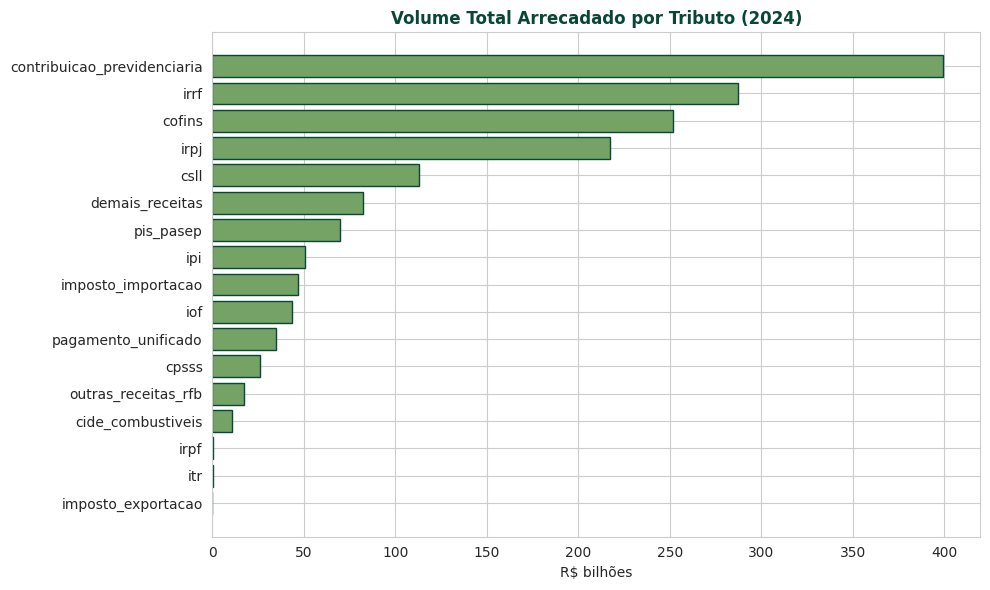

In [ ]:
soma_tributos = dados[tributos].sum().sort_values(ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(soma_tributos.index, soma_tributos.values / 1e9, color='#75A365', edgecolor='#084734')
plt.title('Volume Total Arrecadado por Tributo (2024)', color='#084734', fontweight='bold')
plt.xlabel('R$ bilhões')
plt.tight_layout()
plt.show()

*Medidas de posição e dispersão — Contribuição Previdenciária (maior tributo)*

Análise detalhada para o tributo de maior arrecadação. Por haver muitas naturezas com valor zero, calculamos também as medidas considerando apenas os registros positivos.

In [ ]:
# describe completo
dados['contribuicao_previdenciaria'].describe()

,contribuicao_previdenciaria
count,8.100000e+01
mean,4.931496e+09
std,2.265338e+10
min,0.000000e+00
25%,1.598379e+06
50%,1.376453e+08
75%,1.127164e+09
max,1.957305e+11


In [ ]:
# Apenas registros > 0
sem_zero = dados[dados['contribuicao_previdenciaria'] > 0]['contribuicao_previdenciaria']

print('Quartis (>0):')
print(sem_zero.quantile([0.25, 0.50, 0.75]))
print('\nPercentis 1 e 99 (>0):')
print(sem_zero.quantile([0.01, 0.99]))
print('\nDesvio padrão:', round(sem_zero.std(), 1))
print('Coeficiente de variação:', round(sem_zero.std() / sem_zero.mean()))
print('Amplitude:', round(sem_zero.max() - sem_zero.min(), 1))
print('Amplitude percentílica (P99-P1):', round(sem_zero.quantile(0.99) - sem_zero.quantile(0.01), 1))

Quartis (>0):
0.25    2.557087e+06
0.50    2.196795e+08
0.75    1.146463e+09
Name: contribuicao_previdenciaria, dtype: float64

Percentis 1 e 99 (>0):
0.01    2.237648e+04
0.99    8.559208e+10
Name: contribuicao_previdenciaria, dtype: float64

Desvio padrão: 23212896015.0
Coeficiente de variação: 4
Amplitude: 195730456467.8
Amplitude percentílica (P99-P1): 85592061053.0


# **5. Análise de valores atípicos**

Avaliamos os outliers de duas formas: (a) visualmente, via **boxplot** dos 3 maiores tributos; e (b) numericamente, comparando **máximo × percentil 99 × limite superior (P99 + 75%)**. A conclusão geral é que os extremos correspondem às grandes naturezas empresariais — comportamento legítimo de negócio, e não erro de base.

*Boxplots dos 3 maiores tributos + Top 5 registros de cada*

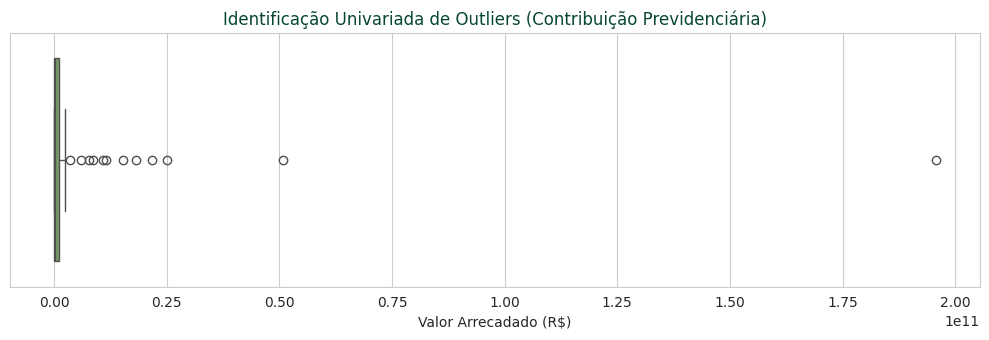

--- Top 5 maiores registros: Contribuição Previdenciária ---
 natureza_juridica_codigo   natureza_juridica_descricao  contribuicao_previdenciaria
                     2062 Sociedade Empresária Limitada                 1.957305e+11
                     2054     Sociedade Anônima Fechada                 5.081154e+10
                     1244                     Município                 2.514142e+10
                     2046      Sociedade Anônima Aberta                 2.183760e+10
                     2135       Empresário (Individual)                 1.810536e+10


In [ ]:
# Contribuição Previdenciária
plt.figure(figsize=(10, 3.5))
sns.boxplot(data=dados, x='contribuicao_previdenciaria', color='#75A365')
plt.title('Identificação Univariada de Outliers (Contribuição Previdenciária)', color='#084734')
plt.xlabel('Valor Arrecadado (R$)')
plt.tight_layout()
plt.show()

print("--- Top 5 maiores registros: Contribuição Previdenciária ---")
top5 = dados.sort_values(by='contribuicao_previdenciaria', ascending=False).head(5)
print(top5[['natureza_juridica_codigo', 'natureza_juridica_descricao', 'contribuicao_previdenciaria']].to_string(index=False))

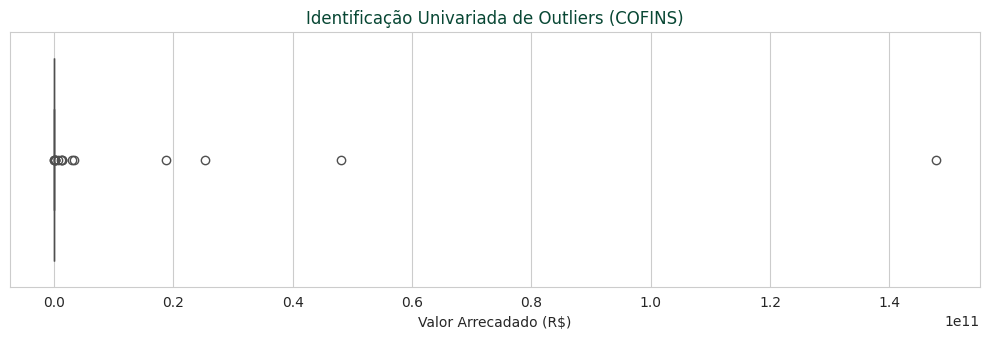

--- Top 5 maiores registros: COFINS ---
 natureza_juridica_codigo   natureza_juridica_descricao       cofins
                     2062 Sociedade Empresária Limitada 1.477876e+11
                     2054     Sociedade Anônima Fechada 4.805240e+10
                     2038   Sociedade de Economia Mista 2.533786e+10
                     2046      Sociedade Anônima Aberta 1.880998e+10
                     2135       Empresário (Individual) 3.291864e+09


In [ ]:
# COFINS
plt.figure(figsize=(10, 3.5))
sns.boxplot(data=dados, x='cofins', color='#75A365')
plt.title('Identificação Univariada de Outliers (COFINS)', color='#084734')
plt.xlabel('Valor Arrecadado (R$)')
plt.tight_layout()
plt.show()

print("--- Top 5 maiores registros: COFINS ---")
top5 = dados.sort_values(by='cofins', ascending=False).head(5)
print(top5[['natureza_juridica_codigo', 'natureza_juridica_descricao', 'cofins']].to_string(index=False))

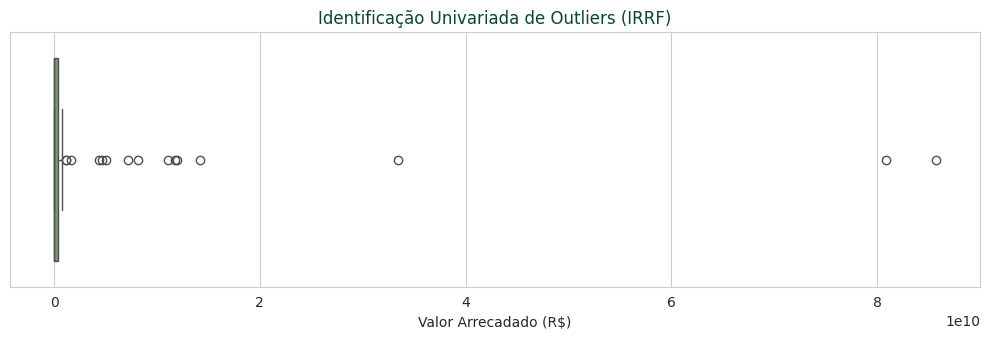

--- Top 5 maiores registros: IRRF ---
 natureza_juridica_codigo              natureza_juridica_descricao         irrf
                     2054                Sociedade Anônima Fechada 8.571765e+10
                     2062            Sociedade Empresária Limitada 8.083369e+10
                     2046                 Sociedade Anônima Aberta 3.346927e+10
                     2038              Sociedade de Economia Mista 1.422394e+10
                     1015 Órgão Público do Poder Executivo Federal 1.195182e+10


In [ ]:
# IRRF
plt.figure(figsize=(10, 3.5))
sns.boxplot(data=dados, x='irrf', color='#75A365')
plt.title('Identificação Univariada de Outliers (IRRF)', color='#084734')
plt.xlabel('Valor Arrecadado (R$)')
plt.tight_layout()
plt.show()

print("--- Top 5 maiores registros: IRRF ---")
top5 = dados.sort_values(by='irrf', ascending=False).head(5)
print(top5[['natureza_juridica_codigo', 'natureza_juridica_descricao', 'irrf']].to_string(index=False))

### Avaliação numérica de outlier superior (P99 × Máximo × Limite +75%)

Para cada tributo comparamos o percentil 99, o valor máximo e um limite superior definido como **P99 + 75%**. Mesmo quando o máximo ultrapassa esse limite (margem alta), consideramos aceitável dada a origem das grandes naturezas jurídicas.

In [ ]:
regra_outlier = 0.75
print('--- Colunas com máximo discrepante (acima de P99 + 75%), considerando apenas valores > 0 ---')
for coluna in dados.select_dtypes(include=np.number).columns:
    if coluna in ['natureza_juridica_codigo', 'total_natureza', 'qtd_tributos']:
        continue
    valores = dados[coluna][dados[coluna] > 0]
    if len(valores) < 2:
        continue
    p99 = valores.quantile(0.99)
    limite_superior = p99 * (1 + regra_outlier)
    if valores.max() > limite_superior:
        print(f'  {coluna}: máx={valores.max()/1e9:.1f} bi | limite={limite_superior/1e9:.1f} bi')

--- Colunas com máximo discrepante (acima de P99 + 75%), considerando apenas valores > 0 ---
  cofins: máx=147.8 bi | limite=143.4 bi
  pis_pasep: máx=31.8 bi | limite=28.5 bi
  contribuicao_previdenciaria: máx=195.7 bi | limite=149.8 bi


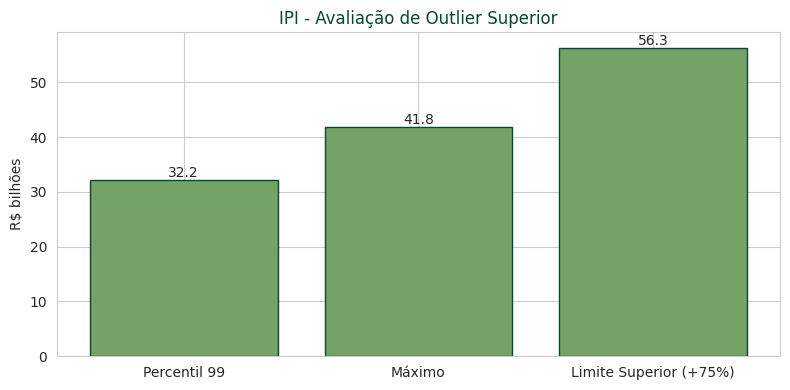

In [ ]:
# IPI — Avaliação de Outlier Superior
grafico = pd.DataFrame({
    'Medida': ['Percentil 99', 'Máximo', 'Limite Superior (+75%)'],
    'Valor': [32161341001.16/1e9, 56282346752.03/1e9, 41806621252.07/1e9] if ['Percentil 99', 'Máximo', 'Limite Superior (+75%)'][1]=='Limite Superior (+75%)' else [32161341001.16/1e9, 41806621252.07/1e9, 56282346752.03/1e9]
})
# Reordena conforme rótulos
mapa = {'Percentil 99': 32161341001.16/1e9, 'Limite Superior (+75%)': 56282346752.03/1e9, 'Máximo': 41806621252.07/1e9}
grafico = pd.DataFrame({'Medida': ['Percentil 99', 'Máximo', 'Limite Superior (+75%)'], 'Valor': [mapa[m] for m in ['Percentil 99', 'Máximo', 'Limite Superior (+75%)']]})

plt.figure(figsize=(8, 4))
bars = plt.bar(grafico['Medida'], grafico['Valor'], color='#75A365', edgecolor='#084734')
plt.ylabel('R$ bilhões')
plt.title('IPI - Avaliação de Outlier Superior', color='#084734')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

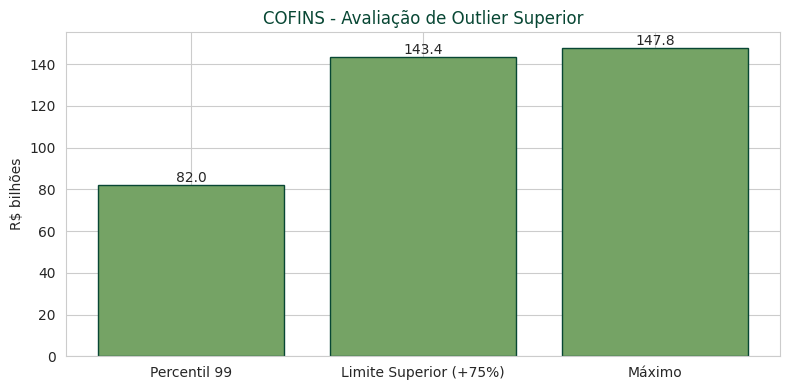

In [ ]:
# COFINS — Avaliação de Outlier Superior
grafico = pd.DataFrame({
    'Medida': ['Percentil 99', 'Limite Superior (+75%)', 'Máximo'],
    'Valor': [81962382880.58/1e9, 143434170041.02/1e9, 147787643810.14/1e9] if ['Percentil 99', 'Limite Superior (+75%)', 'Máximo'][1]=='Limite Superior (+75%)' else [81962382880.58/1e9, 147787643810.14/1e9, 143434170041.02/1e9]
})
# Reordena conforme rótulos
mapa = {'Percentil 99': 81962382880.58/1e9, 'Limite Superior (+75%)': 143434170041.02/1e9, 'Máximo': 147787643810.14/1e9}
grafico = pd.DataFrame({'Medida': ['Percentil 99', 'Limite Superior (+75%)', 'Máximo'], 'Valor': [mapa[m] for m in ['Percentil 99', 'Limite Superior (+75%)', 'Máximo']]})

plt.figure(figsize=(8, 4))
bars = plt.bar(grafico['Medida'], grafico['Valor'], color='#75A365', edgecolor='#084734')
plt.ylabel('R$ bilhões')
plt.title('COFINS - Avaliação de Outlier Superior', color='#084734')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Imposto de Exportação — variável de baixa capacidade informativa

O Imposto de Exportação é praticamente nulo para a maioria das naturezas jurídicas, concentrando a arrecadação em poucas categorias. Por possuir baixíssima variabilidade, gera correlações NaN ou estatisticamente irrelevantes — devendo ser documentado como **variável de baixa capacidade informativa** para análises de correlação, e **não** como erro da base de dados.

In [ ]:
# Casos em que o imposto de exportação é igual a zero
dados[dados['imposto_exportacao'] == 0].shape[0]

75

In [ ]:
# Casos em que o imposto de exportação é maior que zero
dados[dados['imposto_exportacao'] > 0].shape[0]

6

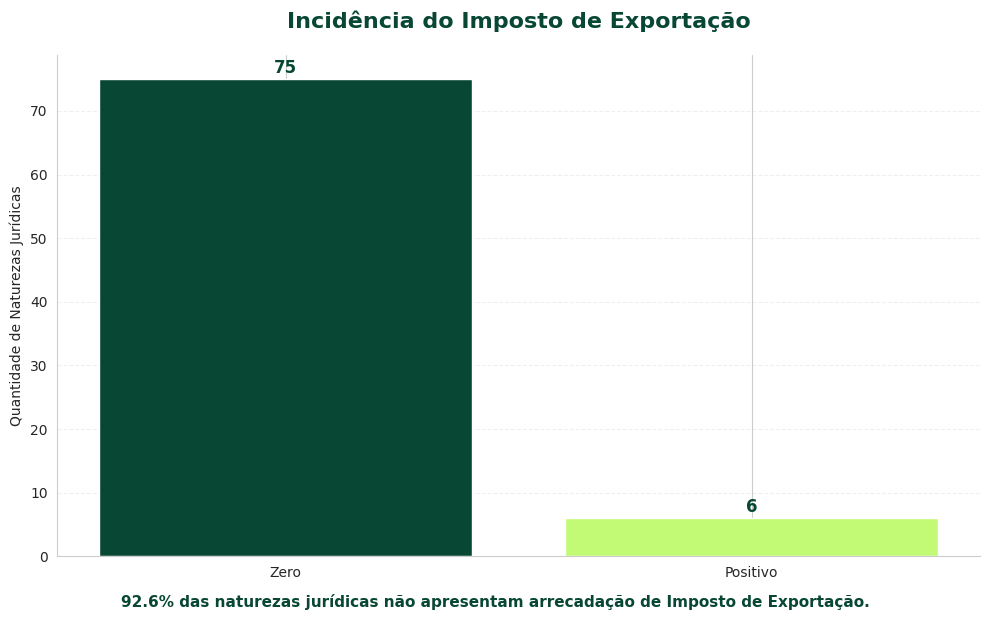

In [ ]:
# Incidência do Imposto de Exportação
categorias = ['Zero', 'Positivo']
valores = [(dados['imposto_exportacao'] == 0).sum(), (dados['imposto_exportacao'] > 0).sum()]
cores = ['#084734', '#C3FA75']

plt.figure(figsize=(10, 6))
barras = plt.bar(categorias, valores, color=cores, width=0.8)
plt.title('Incidência do Imposto de Exportação', fontsize=16, fontweight='bold', color='#084734', pad=20)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylabel('Quantidade de Naturezas Jurídicas')
for barra in barras:
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1,
             f'{barra.get_height()}', ha='center', fontsize=12, fontweight='bold', color='#084734')
pct = valores[0] / sum(valores) * 100
plt.figtext(0.5, -0.02, f'{pct:.1f}% das naturezas jurídicas não apresentam arrecadação de Imposto de Exportação.',
            ha='center', fontsize=11, fontweight='bold', color='#084734')
plt.tight_layout()
plt.show()

# **6. Análise bivariada**

A análise de correlação só faz sentido entre variáveis **quantitativas**. Por isso, retiramos as três colunas de identificação (`natureza_juridica_codigo`, `natureza_juridica_descricao`, `natureza_juridica_escopo`) — o código, embora numérico, é apenas um identificador.

In [ ]:
tributos_corr = dados.select_dtypes('number').drop(
    columns=['natureza_juridica_codigo', 'total_natureza', 'qtd_tributos'])

### Método escolhido para as correlações

Por termos uma base com outliers grandes e muito assimétrica, optamos pela correlação de **Spearman** (baseada em postos), menos sensível a valores extremos do que Pearson.

In [ ]:
corr_spearman = tributos_corr.corr(method='spearman')
corr_spearman.round(2)

,imposto_importacao,imposto_exportacao,ipi,irpf,irpj,irrf,iof,itr,cofins,pis_pasep,csll,cide_combustiveis,contribuicao_previdenciaria,cpsss,pagamento_unificado,outras_receitas_rfb,demais_receitas
imposto_importacao,1.00,0.53,0.90,0.65,0.66,0.62,0.75,0.75,0.73,0.61,0.68,0.82,0.60,0.34,0.65,0.68,0.66
imposto_exportacao,0.53,1.00,0.53,0.61,0.43,0.42,0.48,0.48,0.44,0.41,0.43,0.48,0.44,0.31,0.40,0.43,0.41
ipi,0.90,0.53,1.00,0.65,0.68,0.58,0.69,0.66,0.73,0.55,0.68,0.73,0.53,0.35,0.61,0.70,0.62
irpf,0.65,0.61,0.65,1.00,0.53,0.51,0.60,0.63,0.56,0.48,0.53,0.65,0.51,0.32,0.50,0.52,0.52
irpj,0.66,0.43,0.68,0.53,1.00,0.61,0.60,0.67,0.84,0.55,0.87,0.63,0.43,0.39,0.68,0.62,0.68
irrf,0.62,0.42,0.58,0.51,0.61,1.00,0.57,0.59,0.68,0.60,0.66,0.72,0.71,0.53,0.78,0.66,0.77
iof,0.75,0.48,0.69,0.60,0.60,0.57,1.00,0.65,0.67,0.55,0.66,0.74,0.55,0.31,0.63,0.64,0.59
itr,0.75,0.48,0.66,0.63,0.67,0.59,0.65,1.00,0.69,0.64,0.68,0.75,0.60,0.47,0.64,0.67,0.67
cofins,0.73,0.44,0.73,0.56,0.84,0.68,0.67,0.69,1.00,0.73,0.94,0.75,0.65,0.41,0.82,0.74,0.71
pis_pasep,0.61,0.41,0.55,0.48,0.55,0.60,0.55,0.64,0.73,1.00,0.68,0.66,0.88,0.52,0.77,0.84,0.75


*Visualização da matriz de Spearman como mapa de calor*

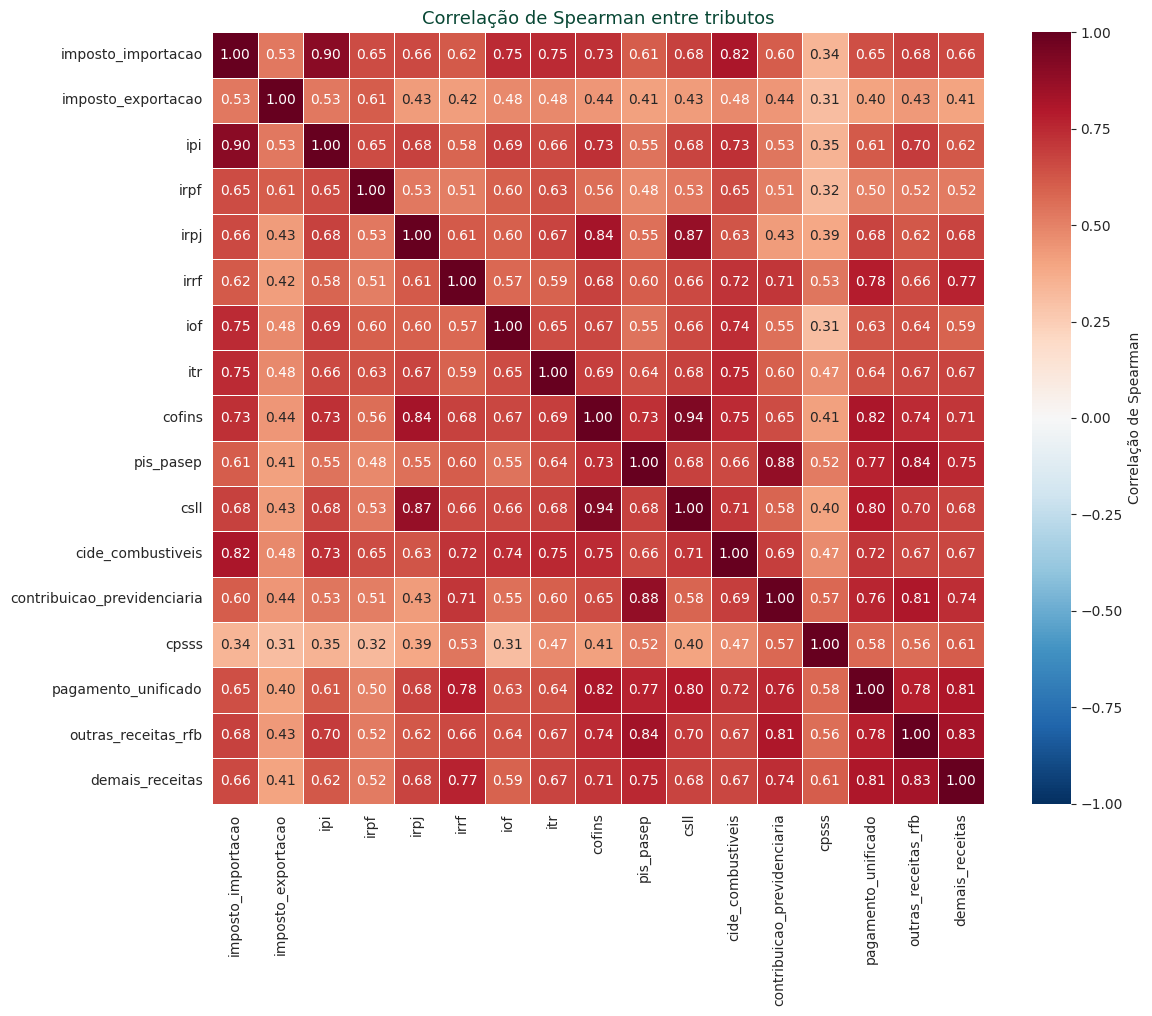

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlação de Spearman'})
plt.title('Correlação de Spearman entre tributos', fontsize=13, color='#084734')
plt.tight_layout()
plt.show()

### Três blocos de relações se destacam

- **Bloco 1 — Lucro/Faturamento:** COFINS × CSLL (0,94), IRPJ × CSLL (0,87), IRPJ × COFINS (0,84)
- **Bloco 2 — Comércio exterior:** Imposto de Importação × IPI (0,90)
- **Bloco 3 — Folha de pagamento:** PIS/PASEP × Contribuição Previdenciária (0,88)

#### Bloco 1: COFINS × CSLL × IRPJ

In [ ]:
# Variáveis utilizadas
var1   = dados['cofins']
var2 = dados['csll']
var3 = dados['irpj']

In [ ]:
filtro1 = (var1 > 0) & (var2 > 0) & (var3 > 0)
var1_f = var1[filtro1]
var2_f = var2[filtro1]
var3_f = var3[filtro1]

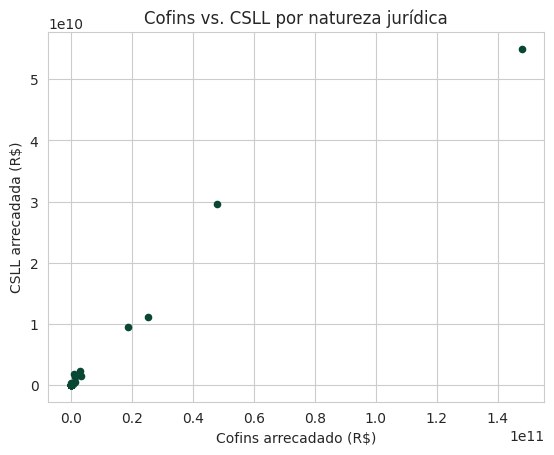

In [ ]:
# Plotagem
plt.scatter(var1_f,
            var2_f,
            color='#084734',
            marker='o',   # 'o' círculo, 's' quadrado, 'x' cruz, 'D' diamante
            s=20)

plt.title("Cofins vs. CSLL por natureza jurídica")
plt.xlabel('Cofins arrecadado (R$)')
plt.ylabel('CSLL arrecadada (R$)')

plt.show()

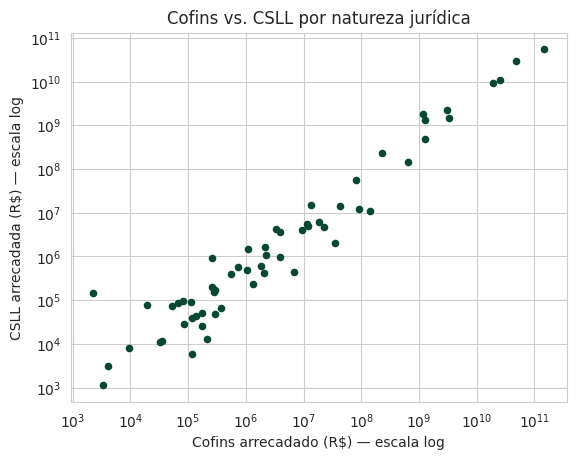

In [ ]:
# Plotagem com escala logarítmica
plt.scatter(var1_f,
            var2_f,
            color='#084734',
            marker='o',   # 'o' círculo, 's' quadrado, 'x' cruz, 'D' diamante
            s=20)

plt.xscale('log')   # escala log no eixo x
plt.yscale('log')   # escala log no eixo y

plt.title("Cofins vs. CSLL por natureza jurídica")
plt.xlabel('Cofins arrecadado (R$) — escala log')
plt.ylabel('CSLL arrecadada (R$) — escala log')

plt.show()

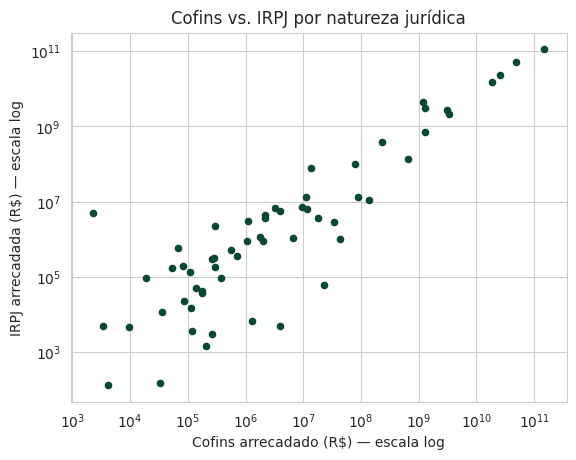

In [ ]:
# Plotagem com escala logarítmica
plt.scatter(var1_f,
            var3_f,
            color='#084734',
            marker='o',   # 'o' círculo, 's' quadrado, 'x' cruz, 'D' diamante
            s=20)

plt.xscale('log')   # escala log no eixo x
plt.yscale('log')   # escala log no eixo y

plt.title("Cofins vs. IRPJ por natureza jurídica")
plt.xlabel('Cofins arrecadado (R$) — escala log')
plt.ylabel('IRPJ arrecadada (R$) — escala log')

plt.show()

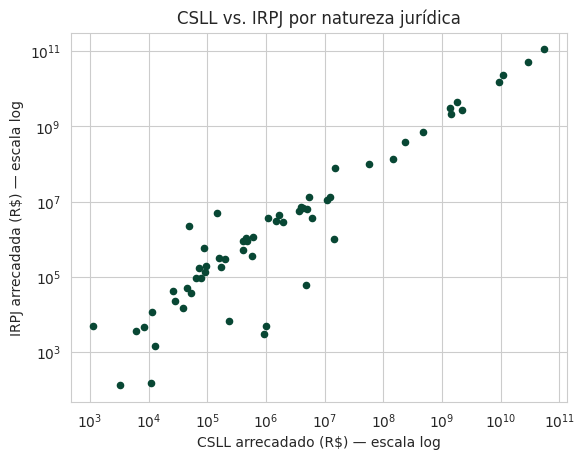

In [ ]:
# Plotagem com escala logarítmica
plt.scatter(var2_f,
            var3_f,
            color='#084734',
            marker='o',   # 'o' círculo, 's' quadrado, 'x' cruz, 'D' diamante
            s=20)

plt.xscale('log')   # escala log no eixo x
plt.yscale('log')   # escala log no eixo y

plt.title("CSLL vs. IRPJ por natureza jurídica")
plt.xlabel('CSLL arrecadado (R$) — escala log')
plt.ylabel('IRPJ arrecadada (R$) — escala log')

plt.show()

#### Bloco 2: Imposto de Importação × IPI

In [ ]:
# Variáveis utilizadas
var4   = dados['imposto_importacao']
var5 = dados['ipi']

In [ ]:
filtro2 = (var4 > 0) & (var5 > 0)
var4_f = var4[filtro2]
var5_f = var5[filtro2]

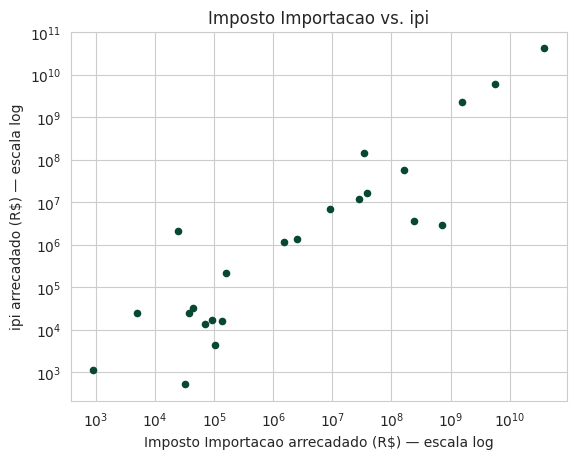

In [ ]:
# Plotagem com escala logarítmica
plt.scatter(var4_f,
            var5_f,
            color='#084734',
            marker='o',   # 'o' círculo, 's' quadrado, 'x' cruz, 'D' diamante
            s=20)

plt.xscale('log')   # escala log no eixo x
plt.yscale('log')   # escala log no eixo y

plt.title("Imposto Importacao vs. ipi")
plt.xlabel('Imposto Importacao arrecadado (R$) — escala log')
plt.ylabel('ipi arrecadado (R$) — escala log')

plt.show()

#### Bloco 3: PIS/PASEP × Contribuição Previdenciária

In [ ]:
# Variáveis utilizadas
var6 = dados['pis_pasep']
var7 = dados['contribuicao_previdenciaria']

In [ ]:
filtro3 = (var6 > 0) & (var7 > 0)
var6_f = var6[filtro3]
var7_f = var7[filtro3]

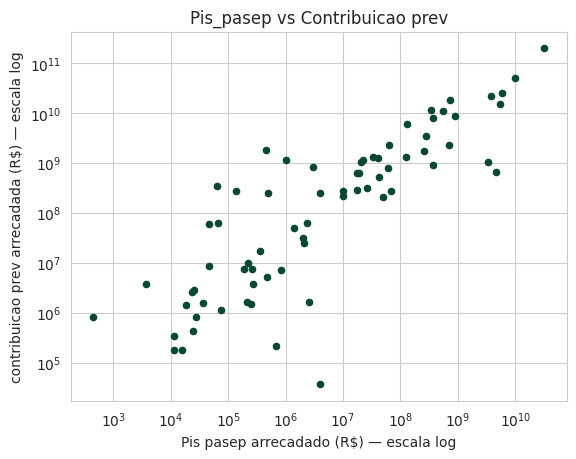

In [ ]:
# Plotagem com escala logarítmica
plt.scatter(var6_f,
            var7_f,
            color='#084734',
            marker='o',   # 'o' círculo, 's' quadrado, 'x' cruz, 'D' diamante
            s=20)

plt.xscale('log')   # escala log no eixo x
plt.yscale('log')   # escala log no eixo y

plt.title("Pis_pasep vs Contribuicao prev")
plt.xlabel('Pis pasep arrecadado (R$) — escala log')
plt.ylabel('contribuicao prev arrecadada (R$) — escala log')

plt.show()

# **7. Conclusões — resposta às perguntas do caso**

**Distribuição:** a arrecadação federal de 2024 (~R$ 1,65 trilhão) é fortemente concentrada. Os 3 maiores tributos (Contribuição Previdenciária, IRRF e COFINS) somam ~57% do total, e 4 naturezas jurídicas concentram ~82% — com a Sociedade Empresária Limitada respondendo sozinha por ~45%.

**Valores atípicos:** os extremos identificados nos boxplots e na avaliação por percentis correspondem às grandes naturezas empresariais (Ltda e S.A.). Não são erros nem outliers a descartar: refletem a materialidade financeira real dessas categorias — comportamento legítimo e esperado do negócio. O Imposto de Exportação é a exceção, documentado como variável de baixa capacidade informativa.

**Correlação — sim, existe correlação relevante entre tributos dentro da visão por natureza jurídica:**

1. **Lucro e faturamento — COFINS × CSLL × IRPJ (par mais forte da base).** A CSLL incide sobre o lucro e a COFINS sobre o faturamento; uma empresa com grande operação gera os dois simultaneamente. O IRPJ (também sobre o lucro) se liga ao mesmo núcleo de tributos empresariais.

2. **Comércio exterior e indústria — Imposto de Importação × IPI (0,90).** Atuam em cascata: na importação, o IPI incide também sobre o valor do Imposto de Importação. Naturezas importadoras concentram os dois.

3. **Folha de pagamento — PIS/PASEP × Contribuição Previdenciária (0,88).** Ambos associados à remuneração e ao quadro de empregados.

**Resposta direta:** dentro de uma mesma natureza jurídica, os tributos se correlacionam fortemente, com destaque para os blocos de **lucro/faturamento**, **comércio exterior** e **folha de pagamento**.
